# MD analyses for orth2 trajectory
Using the LAMMPS trajectory (`orth2.lammpstrj`). Assumes first 3,840 atoms are APAP (192 molecules x 20 atoms) followed by water (3 atoms each).

In [23]:
# Optional: install if the environment misses these packages
# !pip install mdanalysis mdtraj nglview pandas seaborn matplotlib tqdm

In [24]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import MDAnalysis as mda
from MDAnalysis.analysis import distances
from MDAnalysis.analysis.rdf import InterRDF
from MDAnalysis.analysis.msd import EinsteinMSD

try:
    from MDAnalysis.analysis.sasa import ShrakeRupley
    HAS_SASA = True
except Exception:
    HAS_SASA = False
    ShrakeRupley = None
    print('ShrakeRupley not available; SASA section will be skipped.')

traj_file = Path('ortho1.lammpstrj')
assert traj_file.exists(), 'ortho1.lammpstrj not found.'

masses = {1:12.011,2:12.011,3:12.011,4:1.008,5:1.008,6:1.008,7:14.007,8:15.999,9:15.999,10:15.999,11:1.008}

u = mda.Universe(str(traj_file), format='LAMMPSDUMP', guess_bonds=False)

apap_atoms = 3840
atoms_per_apap = 20
water_atoms = u.atoms.n_atoms - apap_atoms
atoms_per_water = 3
apap_mols = apap_atoms // atoms_per_apap
water_mols = water_atoms // atoms_per_water

molnums = np.concatenate([
    np.repeat(np.arange(1, apap_mols+1), atoms_per_apap),
    np.repeat(np.arange(apap_mols+1, apap_mols+water_mols+1), atoms_per_water)
])

u.add_TopologyAttr('masses', [masses.get(int(t), 12.0) for t in u.atoms.types.astype(int)])

apap = u.atoms[:apap_atoms]
apap_heavy = apap.select_atoms('type 1 2 3 7 8 9')
water = u.atoms[apap_atoms:]
water_O = water.select_atoms('type 10')
water_H = water.select_atoms('type 11')

apap_mol_ids = np.arange(1, apap_mols+1)
apap_heavy_molnums = molnums[:apap_atoms][apap_heavy.indices]

stride = 10
print(f"Frames: {u.trajectory.n_frames}, APAP atoms: {apap_atoms} ({apap_mols} mols), water atoms: {water.n_atoms} ({water_mols} mols).")


ShrakeRupley not available; SASA section will be skipped.


/Users/jc/miniconda3/lib/python3.13/site-packages/MDAnalysis/topology/LAMMPSParser.py:670: UserWarning: Guessed all Masses to 1.0
  warnings.warn("Guessed all Masses to 1.0")


Frames: 677, APAP atoms: 3840 (192 mols), water atoms: 77280 (25760 mols).


/Users/jc/miniconda3/lib/python3.13/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


In [25]:

import numpy as np

def largest_cluster_mols(group: mda.core.groups.AtomGroup, mol_ids: np.ndarray, box, cutoff=4.5):
    coords = group.positions
    dmat = distances.distance_array(coords, coords, box=box)
    adjacency = dmat < cutoff
    np.fill_diagonal(adjacency, False)

    graph = {i: set() for i in range(len(coords))}
    rows, cols = np.where(adjacency)
    for i, j in zip(rows, cols):
        if mol_ids[i] == mol_ids[j]:
            continue
        graph[i].add(j)
        graph[j].add(i)

    visited = set()
    largest = set()
    for start in range(len(coords)):
        if start in visited:
            continue
        stack = [start]
        component_mols = set()
        while stack:
            idx = stack.pop()
            if idx in visited:
                continue
            visited.add(idx)
            component_mols.add(mol_ids[idx])
            for nb in graph[idx]:
                if nb not in visited:
                    stack.append(nb)
        if len(component_mols) > len(largest):
            largest = component_mols
    return set(map(int, largest))


def rolling_time(ts):
    return ts.time


## 2.1 Crystal dissolution curve

Initial cluster size (mols): 185


  0%|          | 0/68 [00:00<?, ?it/s]

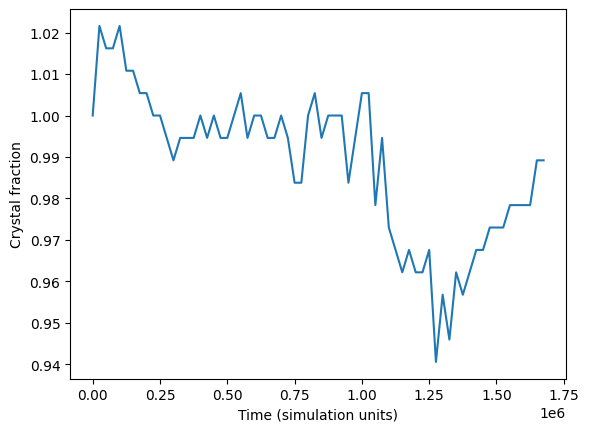

In [26]:

dissolution = []
u.trajectory[0]
initial_cluster = largest_cluster_mols(apap_heavy, apap_heavy_molnums, u.dimensions, cutoff=4.5)
initial_size = len(initial_cluster)
print(f"Initial cluster size (mols): {initial_size}")

for ts in tqdm(u.trajectory[::stride]):
    cluster = largest_cluster_mols(apap_heavy, apap_heavy_molnums, ts.dimensions, cutoff=4.5)
    frac = len(cluster) / initial_size if initial_size else 0.0
    dissolution.append({'time': rolling_time(ts), 'cluster_size': len(cluster), 'fraction': frac})

dissolution_df = pd.DataFrame(dissolution)
fig, ax = plt.subplots()
ax.plot(dissolution_df['time'], dissolution_df['fraction'])
ax.set_xlabel('Time (simulation units)')
ax.set_ylabel('Crystal fraction')
plt.show()


## 2.2 Radial Distribution Function (RDF)

/Users/jc/miniconda3/lib/python3.13/site-packages/MDAnalysis/analysis/rdf.py:430: DeprecationWarning: The `bins` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.bins` instead
  warnings.warn(wmsg, DeprecationWarning)
/Users/jc/miniconda3/lib/python3.13/site-packages/MDAnalysis/analysis/rdf.py:440: DeprecationWarning: The `rdf` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rdf` instead
  warnings.warn(wmsg, DeprecationWarning)


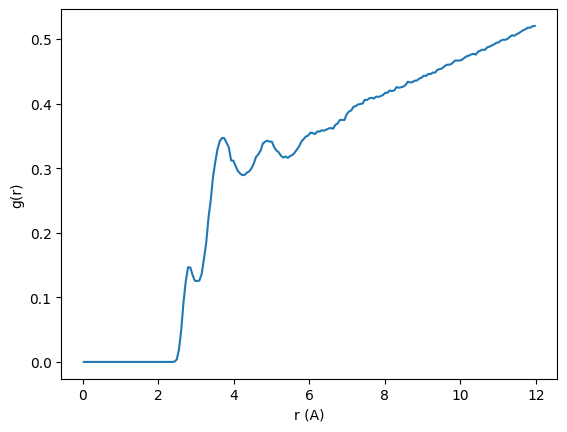

In [27]:

rdf = InterRDF(apap_heavy, water_O, nbins=200, range=(0.0, 12.0))
rdf.run(step=stride)
fig, ax = plt.subplots()
ax.plot(rdf.bins, rdf.rdf)
ax.set_xlabel('r (A)')
ax.set_ylabel('g(r)')
plt.show()


## 2.3 Coordination number vs time

  0%|          | 0/68 [00:00<?, ?it/s]

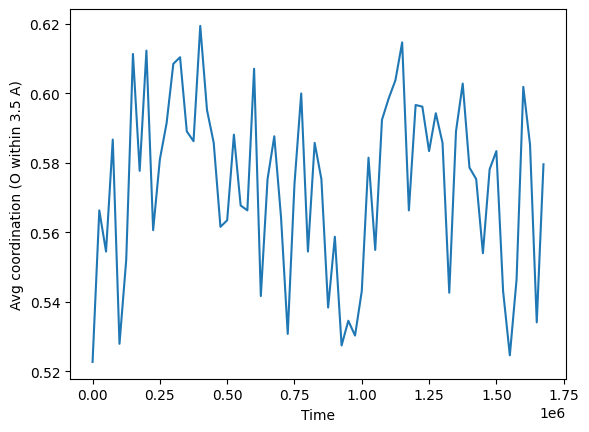

In [28]:

coord_records = []
cutoff_cn = 3.5
for ts in tqdm(u.trajectory[::stride]):
    dmat = distances.distance_array(apap_heavy.positions, water_O.positions, box=ts.dimensions)
    within = (dmat < cutoff_cn).sum(axis=1)
    coord_records.append({'time': rolling_time(ts), 'coordination': within.mean(), 'max_coord': within.max()})
coord_df = pd.DataFrame(coord_records)
fig, ax = plt.subplots()
ax.plot(coord_df['time'], coord_df['coordination'])
ax.set_xlabel('Time')
ax.set_ylabel('Avg coordination (O within 3.5 A)')
plt.show()


## 2.4 Hydrogen-bond analysis

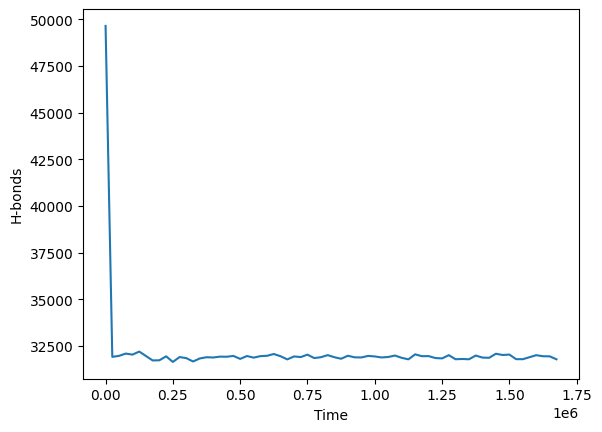

In [29]:
from MDAnalysis.analysis.hydrogenbonds import HydrogenBondAnalysis

hbond = HydrogenBondAnalysis(
    universe=u,
    donors_sel='type 7 8 9 10',
    hydrogens_sel='type 4 5 6 11',
    acceptors_sel='type 7 8 9 10',
    d_h_cutoff=1.2,
    d_a_cutoff=3.5,
    d_h_a_angle_cutoff=150,
)
hbond.run(step=stride)

hb_counts = hbond.count_by_time()
hb_times = hbond.times
fig, ax = plt.subplots()
ax.plot(hb_times, hb_counts)
ax.set_xlabel('Time')
ax.set_ylabel('H-bonds')
plt.show()


## 2.5 Radius of gyration (Rg) of APAP molecules

  0%|          | 0/68 [00:00<?, ?it/s]

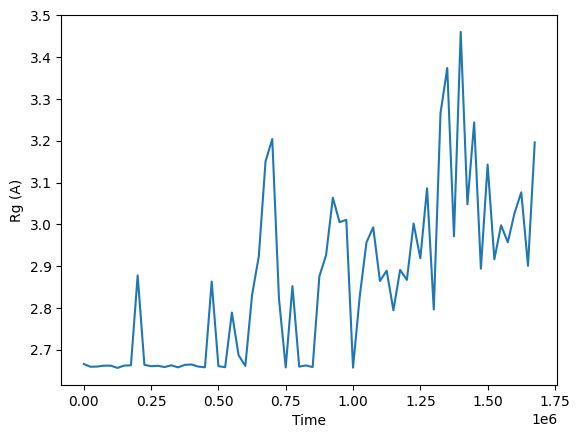

In [30]:

apap_by_mol = {mol: apap[(mol-1)*atoms_per_apap: mol*atoms_per_apap] for mol in apap_mol_ids}
rg_records = []
for ts in tqdm(u.trajectory[::stride]):
    for mol, group in apap_by_mol.items():
        rg = group.radius_of_gyration()
        rg_records.append({'time': rolling_time(ts), 'mol': mol, 'rg': rg})
rg_df = pd.DataFrame(rg_records)
fig, ax = plt.subplots()
ax.plot(rg_df.groupby('time')['rg'].mean())
ax.set_xlabel('Time')
ax.set_ylabel('Rg (A)')
plt.show()


## 2.6 COM distance of each APAP molecule from crystal core

  0%|          | 0/68 [00:00<?, ?it/s]

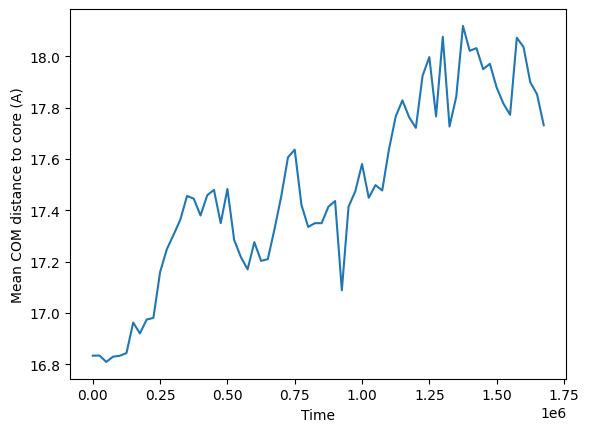

In [31]:

core_indices = np.concatenate([np.arange((mol-1)*atoms_per_apap, mol*atoms_per_apap) for mol in initial_cluster])
core_group = apap[core_indices]
com_records = []
for ts in tqdm(u.trajectory[::stride]):
    core_com = core_group.center_of_mass()
    for mol, group in apap_by_mol.items():
        com = group.center_of_mass()
        dist = distances.distance_array(core_com.reshape(1,3), com.reshape(1,3), box=ts.dimensions)[0,0]
        com_records.append({'time': rolling_time(ts), 'mol': mol, 'core_distance': dist})
com_df = pd.DataFrame(com_records)
fig, ax = plt.subplots()
ax.plot(com_df.groupby('time')['core_distance'].mean())
ax.set_xlabel('Time')
ax.set_ylabel('Mean COM distance to core (A)')
plt.show()


## 2.7 Mean Squared Displacement (MSD)

100%|██████████| 676/676 [04:06<00:00,  2.74it/s]


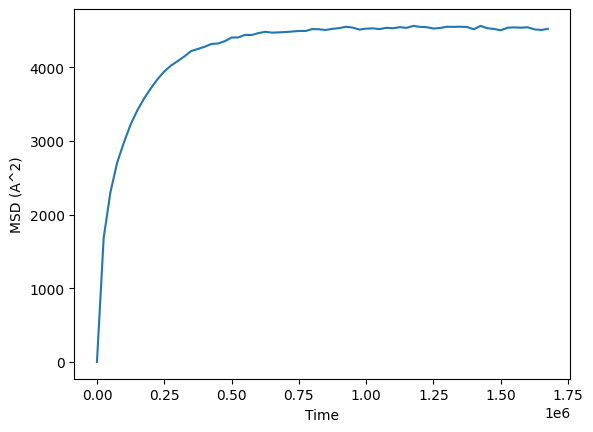

Diffusion coefficient (tail fit, 55 points): 2.8402e-05 A^2/ps


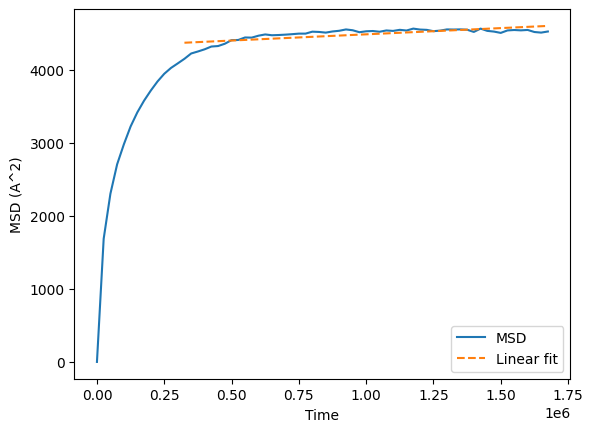

In [32]:
from MDAnalysis.analysis.msd import EinsteinMSD

# Try EinsteinMSD; fall back to reference-frame MSD if no results
msd_calc = EinsteinMSD(u, select='type 10 11', msd_type='xyz', fft=False)
msd_calc.run(step=1)
msd_vals = msd_calc.results.get('msd')
if msd_vals is not None:
    times = msd_calc.times
else:
    sel = u.select_atoms('type 10 11')
    times, msd_vals = [], []
    u.trajectory[0]
    ref = sel.positions.copy()
    for ts in u.trajectory[::stride]:
        disp = sel.positions - ref
        msd_vals.append((disp**2).sum(axis=1).mean())
        times.append(ts.time)

msd_df = pd.DataFrame({'time': times, 'msd': msd_vals})
fig, ax = plt.subplots()
ax.plot(msd_df['time'], msd_df['msd'])
ax.set_xlabel('Time')
ax.set_ylabel('MSD (A^2)')
plt.show()

# Diffusion coefficient from linear fit: MSD = 6 D t in 3D
msd_fit = msd_df.dropna()
if len(msd_fit) >= 2:
    start_idx = int(0.2 * len(msd_fit))  # fit tail (last 80%) to avoid ballistic regime
    fit_slice = msd_fit.iloc[start_idx:]
    slope, intercept = np.polyfit(fit_slice['time'], fit_slice['msd'], 1)
    D = slope / 6.0
    print(f"Diffusion coefficient (tail fit, {len(fit_slice)} points): {D:.4e} A^2/ps")

    fig, ax = plt.subplots()
    ax.plot(msd_df['time'], msd_df['msd'], label='MSD')
    ax.plot(fit_slice['time'], slope * fit_slice['time'] + intercept, '--', label='Linear fit')
    ax.set_xlabel('Time')
    ax.set_ylabel('MSD (A^2)')
    ax.legend()
    plt.show()
else:
    print('Not enough points to fit diffusion coefficient.')


## 2.8 Solvation shell density

  0%|          | 0/68 [00:00<?, ?it/s]

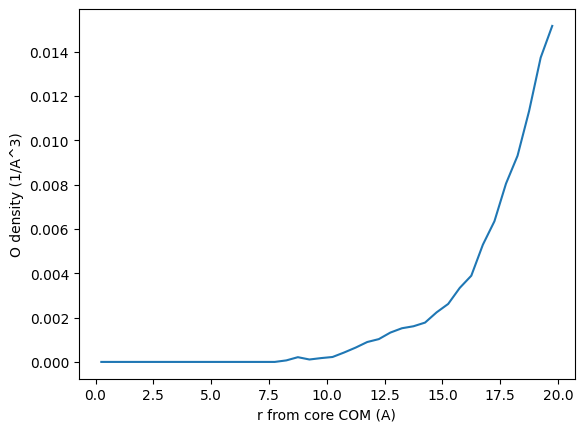

In [33]:

shell_edges = np.linspace(0, 20, 41)
shell_centers = 0.5 * (shell_edges[1:] + shell_edges[:-1])
shell_records = []
for ts in tqdm(u.trajectory[::stride]):
    core_com = core_group.center_of_mass()
    dists = distances.distance_array(core_com.reshape(1,3), water_O.positions, box=ts.dimensions).ravel()
    hist, _ = np.histogram(dists, bins=shell_edges)
    shell_records.append(hist)
shell_array = np.array(shell_records)
density = shell_array.mean(axis=0) / (4/3 * np.pi * (shell_edges[1:]**3 - shell_edges[:-1]**3))
fig, ax = plt.subplots()
ax.plot(shell_centers, density)
ax.set_xlabel('r from core COM (A)')
ax.set_ylabel('O density (1/A^3)')
plt.show()


## 2.9 Contact area of crystal with water (SASA)

In [34]:

if not HAS_SASA:
    print('ShrakeRupley not available; skipping SASA calculation.')
else:
    sasa_records = []
    sr = ShrakeRupley(apap, probe_radius=1.4, n_sphere_points=960)
    for ts in tqdm(u.trajectory[::stride]):
        sr.run(start=ts.frame, stop=ts.frame+1, step=1)
        sasa_records.append({'time': rolling_time(ts), 'sasa': sr.results.total[0]})
    sasa_df = pd.DataFrame(sasa_records)
    fig, ax = plt.subplots()
    ax.plot(sasa_df['time'], sasa_df['sasa'])
    ax.set_xlabel('Time')
    ax.set_ylabel('SASA (A^2)')
    plt.show()


ShrakeRupley not available; skipping SASA calculation.


## 2.10 Lattice parameter evolution

  0%|          | 0/68 [00:00<?, ?it/s]

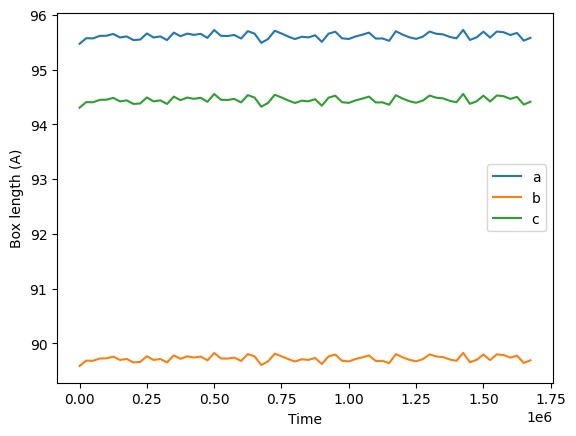

In [35]:

box_records = []
for ts in tqdm(u.trajectory[::stride]):
    lx, ly, lz, xy, xz, yz = ts.dimensions
    box_records.append({'time': rolling_time(ts), 'a': lx, 'b': ly, 'c': lz, 'xy': xy, 'xz': xz, 'yz': yz})
box_df = pd.DataFrame(box_records)
fig, ax = plt.subplots()
for key in ['a', 'b', 'c']:
    ax.plot(box_df['time'], box_df[key], label=key)
ax.set_xlabel('Time')
ax.set_ylabel('Box length (A)')
ax.legend()
plt.show()


## 2.11 Structural groups and interaction parameters

Prepare charges, structural group labels for each APAP molecule, and Lennard-Jones parameters (vdW) used for the energy decompositions.

In [36]:
from collections import defaultdict

# Supercell replication counts and analysis controls
nx, ny, nz = 4, 4, 3
energy_stride = 50
energy_cutoff = 12.0  # LJ + Coulomb cutoff in A
solvation_cutoff = 4.0
COULOMB_CONST = 332.06371  # kcal/mol * A / e^2 (units=real)

atom_type_names = {
    1: 'CG2O1',
    2: 'CG2R61',
    3: 'CG331',
    4: 'HGA3',
    5: 'HGP1',
    6: 'HGR61',
    7: 'NG2S1',
    8: 'OG2D1',
    9: 'OG311',
    10: 'TIP3P-O',
    11: 'TIP3P-H',
}
name_to_type = {v: k for k, v in atom_type_names.items()}

pad_data_path = Path('ortho2_pad.data')
assert pad_data_path.exists(), 'ortho2_pad.data not found (needed for charges/groups).'

def parse_pad_atoms(path: Path):
    n_atoms = None
    bounds = {}
    atoms = []
    with path.open() as fh:
        for line in fh:
            stripped = line.strip()
            if stripped.endswith('atoms') and stripped.split()[0].isdigit():
                n_atoms = int(stripped.split()[0])
            elif stripped.endswith('xlo xhi'):
                bounds['xlo'], bounds['xhi'] = map(float, stripped.split()[:2])
            elif stripped.endswith('ylo yhi'):
                bounds['ylo'], bounds['yhi'] = map(float, stripped.split()[:2])
            elif stripped.endswith('zlo zhi'):
                bounds['zlo'], bounds['zhi'] = map(float, stripped.split()[:2])
            if stripped.startswith('Atoms'):
                break
        if n_atoms is None:
            raise ValueError('Could not read atom count from mono1_pad.data')
        next(fh)  # skip blank/comment line after header
        for _ in range(n_atoms):
            parts = fh.readline().split()
            if not parts:
                continue
            atom_id, mol, atype, charge, x, y, z = parts[:7]
            atoms.append((int(atom_id), int(mol), int(atype), float(charge), float(x), float(y), float(z)))
    atoms.sort(key=lambda x: x[0])
    charges = np.array([a[3] for a in atoms])
    types = np.array([a[2] for a in atoms], dtype=int)
    coords = np.array([[a[4], a[5], a[6]] for a in atoms])
    mol_ids = np.array([a[1] for a in atoms], dtype=int)
    bounds_tuple = (bounds['xlo'], bounds['xhi'], bounds['ylo'], bounds['yhi'], bounds['zlo'], bounds['zhi'])
    return charges, types, coords, mol_ids, bounds_tuple

pad_charges, pad_types, pad_coords, pad_mols, pad_bounds = parse_pad_atoms(pad_data_path)
pad_origin = np.array([pad_bounds[0], pad_bounds[2], pad_bounds[4]])
pad_lengths = np.array([pad_bounds[1] - pad_bounds[0], pad_bounds[3] - pad_bounds[2], pad_bounds[5] - pad_bounds[4]])

# Attach per-atom charges to the trajectory Universe (APAP from data file, TIP3P from mono1.in)
charge_array = np.zeros(u.atoms.n_atoms)
charge_array[:apap_atoms] = pad_charges
water_charge_map = {10: -0.834, 11: 0.417}
water_types = u.atoms.types[apap_atoms:].astype(int)
charge_array[apap_atoms:] = [water_charge_map.get(int(t), 0.0) for t in water_types]
u.add_TopologyAttr('charges', charge_array)


def read_charmm_nonbonded(path: Path, type_lookup: dict):
    params = {}
    in_nb = False
    with path.open() as fh:
        for line in fh:
            stripped = line.strip()
            if not stripped or stripped.startswith('!') or stripped.startswith('#'):
                continue
            # CHARMM NONBONDED
            if stripped.upper().startswith('NONBONDED'):
                in_nb = True
                continue
            if in_nb:
                if stripped.upper().startswith('END'):
                    in_nb = False
                    continue
                parts = stripped.split()
                if len(parts) >= 4 and parts[0].isalpha() and parts[0] in type_lookup:
                    eps = abs(float(parts[2]))
                    rmin_over2 = float(parts[3])
                    sigma = (2.0 * rmin_over2) / (2.0 ** (1/6))
                    params[type_lookup[parts[0]]] = (eps, sigma)
                continue
            # LAMMPS pair_coeff id id eps sigma
            if stripped.startswith('pair_coeff'):
                parts = stripped.split()
                if len(parts) >= 5:
                    try:
                        t1 = int(parts[1].lstrip('${}'))
                        t2 = int(parts[2].lstrip('${}'))
                        eps = float(parts[3]); sigma = float(parts[4])
                    except ValueError:
                        continue
                    if t1 == t2:
                        params[t1] = (eps, sigma)
    return params



# Define crystal box from APAP coordinates (tighter than padded box)
apap_coords = pad_coords[:apap_atoms]  # only APAP atoms
mins = apap_coords.min(axis=0)
maxs = apap_coords.max(axis=0)
crystal_origin = mins
crystal_lengths = maxs - mins + 1e-6  # tiny epsilon to avoid zero width

def assign_structural_groups():
    groups = {}
    for mol in apap_mol_ids:
        start = (mol - 1) * atoms_per_apap
        end = mol * atoms_per_apap
        coords = pad_coords[start:end]
        masses_local = np.array([masses[int(t)] for t in pad_types[start:end]])
        com = np.average(coords, axis=0, weights=masses_local)
        frac = (com - crystal_origin) / crystal_lengths
        ix = int(np.clip(np.floor(frac[0] * nx), 0, nx - 1))
        iy = int(np.clip(np.floor(frac[1] * ny), 0, ny - 1))
        iz = int(np.clip(np.floor(frac[2] * nz), 0, nz - 1))

        extremes = sum([ix in (0, nx - 1), iy in (0, ny - 1), iz in (0, nz - 1)])
        if extremes == 3:
            label = 'Corners'
        elif extremes == 2:
            label = 'Edges'
        elif ix in (0, nx - 1):
            label = '{100} Layer 1'
        elif iy in (0, ny - 1):
            label = '{010} Layer 1'
        elif iz in (0, nz - 1):
            label = '{001} Layer 1'
        elif ix in (1, nx - 2):
            label = '{100} Layer 2'
        elif iy in (1, ny - 2):
            label = '{010} Layer 2'
        elif iz in (1, nz - 2):
            label = '{001} Layer 2'
        else:
            label = 'Interior'
        groups[mol] = label
    return groups


param_candidates = [Path('acetaminophen.params'), Path('par_all36_cgenff.prm')]
lj_params = {t: (0.0, 0.0) for t in range(1, 12)}
# TIP3P vdW from mono1.in
lj_params.update({10: (0.1521, 3.1507), 11: (0.0460, 0.4)})
for prm in param_candidates:
    if prm.exists():
        lj_params.update(read_charmm_nonbonded(prm, name_to_type))
        print(f'Loaded LJ params from {prm}')
        break
else:
    print('Warning: no CHARMM/CGenFF parameter file found; APAP vdW terms will be zero.')

mol_group_map = assign_structural_groups()
print('Group counts:', pd.Series(mol_group_map).value_counts().to_dict())

traj_max_type = int(u.atoms.types.astype(int).max())
param_max_type = max(int(k) for k in lj_params.keys())
max_type = max(traj_max_type, param_max_type)

eps_array = np.zeros(max_type + 1)
sig_array = np.zeros(max_type + 1)
for t, (eps, sig) in lj_params.items():
    idx = int(t)
    if idx >= len(eps_array):
        pad = idx - len(eps_array) + 1
        eps_array = np.pad(eps_array, (0, pad))
        sig_array = np.pad(sig_array, (0, pad))
    eps_array[idx] = eps
    sig_array[idx] = sig

Loaded LJ params from acetaminophen.params
Group counts: {'Edges': 72, '{010} Layer 1': 24, '{100} Layer 1': 24, 'Corners': 24, '{100} Layer 2': 24, '{001} Layer 1': 24}


## 2.12 Per-molecule interaction energies

Compute APAP–APAP (vdW + electrostatic) and APAP–water energies per molecule vs time; solvation counts are gathered in the same loop.

  0%|          | 0/14 [00:00<?, ?it/s]

/Users/jc/miniconda3/lib/python3.13/site-packages/MDAnalysis/coordinates/LAMMPS.py:749: UserWarning: Reader has no dt information, set to 1.0 ps
  ts.data["time"] = step_num * ts.dt


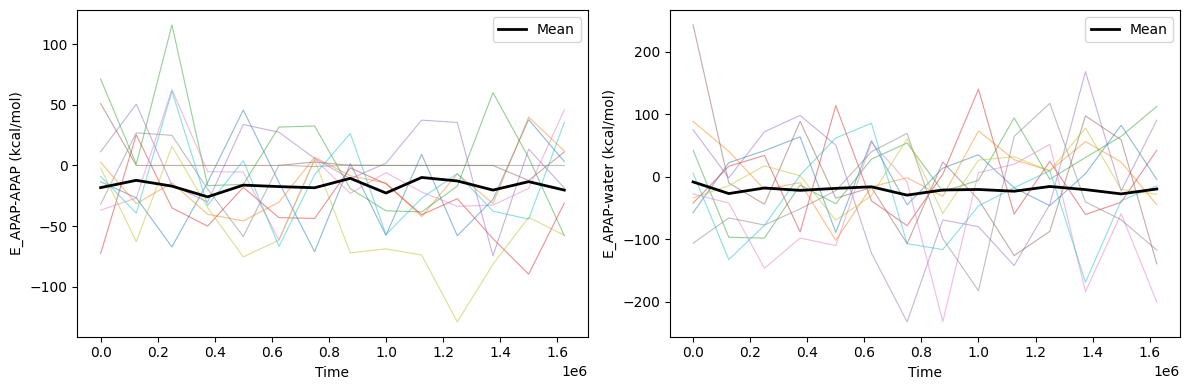

In [37]:
energy_records = []
solvation_records = []
types_all = u.atoms.types.astype(int)
charges_all = u.atoms.charges

for ts in tqdm(u.trajectory[::energy_stride]):
    apap_apap_energy = np.zeros(apap_mols)
    apap_water_energy = np.zeros(apap_mols)
    apap_apap_vdw = np.zeros(apap_mols)
    apap_apap_coul = np.zeros(apap_mols)
    apap_water_vdw = np.zeros(apap_mols)
    apap_water_coul = np.zeros(apap_mols)

    # APAP–APAP pairs (exclude intra-molecular terms)
    pairs_aa, dist_aa = distances.capped_distance(
        apap.positions, apap.positions,
        max_cutoff=energy_cutoff, box=ts.dimensions, return_distances=True
    )
    if len(pairs_aa):
        mask = pairs_aa[:, 0] < pairs_aa[:, 1]
        pairs_aa = pairs_aa[mask]
        dist_aa = dist_aa[mask]
        atoms_i = apap.indices[pairs_aa[:, 0]]
        atoms_j = apap.indices[pairs_aa[:, 1]]
        mol_i = molnums[atoms_i]
        mol_j = molnums[atoms_j]
        inter_mask = mol_i != mol_j
        if inter_mask.any():
            atoms_i = atoms_i[inter_mask]
            atoms_j = atoms_j[inter_mask]
            rij = dist_aa[inter_mask]
            ti = types_all[atoms_i]
            tj = types_all[atoms_j]
            eps_ij = np.sqrt(eps_array[ti] * eps_array[tj])
            sig_ij = 0.5 * (sig_array[ti] + sig_array[tj])
            with np.errstate(divide='ignore'):
                lj = 4 * eps_ij * ((sig_ij / rij) ** 12 - (sig_ij / rij) ** 6)
            coul = COULOMB_CONST * charges_all[atoms_i] * charges_all[atoms_j] / rij
            pair_e = lj + coul
            mol_i = molnums[atoms_i] - 1
            mol_j = molnums[atoms_j] - 1
            np.add.at(apap_apap_energy, mol_i, pair_e)
            np.add.at(apap_apap_energy, mol_j, pair_e)
            np.add.at(apap_apap_vdw, mol_i, lj)
            np.add.at(apap_apap_vdw, mol_j, lj)
            np.add.at(apap_apap_coul, mol_i, coul)
            np.add.at(apap_apap_coul, mol_j, coul)

    # APAP–water pairs
    pairs_aw, dist_aw = distances.capped_distance(
        apap.positions, water.positions,
        max_cutoff=energy_cutoff, box=ts.dimensions, return_distances=True
    )
    if len(pairs_aw):
        atoms_i = apap.indices[pairs_aw[:, 0]]
        atoms_j = water.indices[pairs_aw[:, 1]]
        rij = dist_aw
        ti = types_all[atoms_i]
        tj = types_all[atoms_j]
        eps_ij = np.sqrt(eps_array[ti] * eps_array[tj])
        sig_ij = 0.5 * (sig_array[ti] + sig_array[tj])
        with np.errstate(divide='ignore'):
            lj = 4 * eps_ij * ((sig_ij / rij) ** 12 - (sig_ij / rij) ** 6)
        coul = COULOMB_CONST * charges_all[atoms_i] * charges_all[atoms_j] / rij
        pair_e = lj + coul
        mol_i = molnums[atoms_i] - 1
        np.add.at(apap_water_energy, mol_i, pair_e)
        np.add.at(apap_water_vdw, mol_i, lj)
        np.add.at(apap_water_coul, mol_i, coul)

    # Solvation number within 4 A
    pairs_sol, _ = distances.capped_distance(
        apap.positions, water_O.positions,
        max_cutoff=solvation_cutoff, box=ts.dimensions, return_distances=True
    )
    waters_near = np.unique(water_O.indices[pairs_sol[:, 1]]) if len(pairs_sol) else np.array([], dtype=int)

    time_val = rolling_time(ts)
    for idx, mol in enumerate(apap_mol_ids):
        energy_records.append({
            'time': time_val,
            'mol': mol,
            'e_apap': apap_apap_energy[idx],
            'e_water': apap_water_energy[idx],
            'e_apap_vdw': apap_apap_vdw[idx],
            'e_apap_coul': apap_apap_coul[idx],
            'e_water_vdw': apap_water_vdw[idx],
            'e_water_coul': apap_water_coul[idx],
        })
    solvation_records.append({'time': time_val, 'water_within4A': waters_near.size})

energy_df = pd.DataFrame(energy_records)
solvation_df = pd.DataFrame(solvation_records)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for mol in apap_mol_ids[:10]:  # first ten molecules for visual clarity
    sub = energy_df[energy_df['mol'] == mol]
    axes[0].plot(sub['time'], sub['e_apap'], alpha=0.5, lw=0.8)
    axes[1].plot(sub['time'], sub['e_water'], alpha=0.5, lw=0.8)
mean_apap = energy_df.groupby('time')['e_apap'].mean()
mean_water = energy_df.groupby('time')['e_water'].mean()
axes[0].plot(mean_apap.index, mean_apap.values, color='k', lw=2, label='Mean')
axes[1].plot(mean_water.index, mean_water.values, color='k', lw=2, label='Mean')
axes[0].set_ylabel('E_APAP-APAP (kcal/mol)')
axes[1].set_ylabel('E_APAP-water (kcal/mol)')
axes[0].set_xlabel('Time')
axes[1].set_xlabel('Time')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 2.13 Solvation number fluctuations (water within 4 Å)

Track the number of water molecules within 4 Å of any APAP atom and compare against the mean APAP–water interaction energy.

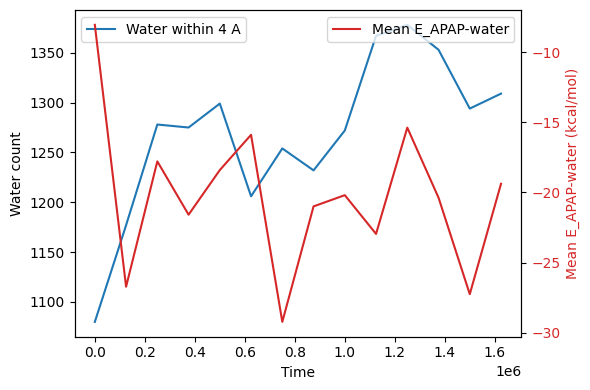

In [38]:
mean_water = energy_df.groupby('time')['e_water'].mean()
fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(solvation_df['time'], solvation_df['water_within4A'], label='Water within 4 A')
ax1.set_xlabel('Time')
ax1.set_ylabel('Water count')

ax2 = ax1.twinx()
ax2.plot(mean_water.index, mean_water.values, color='tab:red', label='Mean E_APAP-water')
ax2.set_ylabel('Mean E_APAP-water (kcal/mol)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()


## 2.14 Group-average energies

Average interaction energies for each structural group (Corners, Edges, and surface layers).

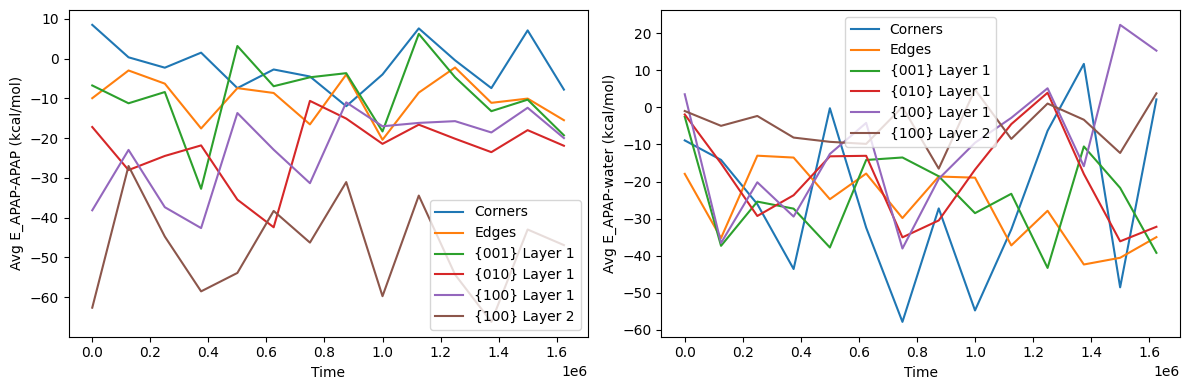

In [39]:
energy_df['group'] = energy_df['mol'].map(mol_group_map)
group_energy = energy_df.dropna(subset=['group']).groupby(['time', 'group'])[['e_apap', 'e_water']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for group_name, sub in group_energy.groupby('group'):
    axes[0].plot(sub['time'], sub['e_apap'], label=group_name)
    axes[1].plot(sub['time'], sub['e_water'], label=group_name)
axes[0].set_xlabel('Time')
axes[1].set_xlabel('Time')
axes[0].set_ylabel('Avg E_APAP-APAP (kcal/mol)')
axes[1].set_ylabel('Avg E_APAP-water (kcal/mol)')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


## 2.15 Correlation: net energy vs % molecules released

Net stabilization from water vs APAP (E_water − E_APAP) plotted against the release profile.

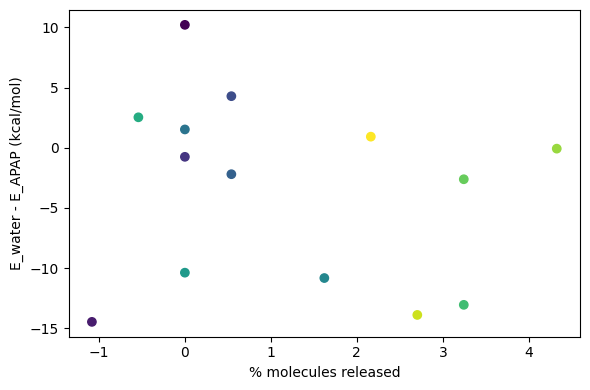

In [40]:
net_df = energy_df.groupby('time')[['e_apap', 'e_water']].mean().reset_index()
net_df['net_energy'] = net_df['e_water'] - net_df['e_apap']

diss_sorted = dissolution_df[['time', 'fraction']].sort_values('time')
net_df = pd.merge_asof(net_df.sort_values('time'), diss_sorted, on='time', direction='nearest')
net_df['released_pct'] = (1.0 - net_df['fraction']) * 100

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(net_df['released_pct'], net_df['net_energy'], c=net_df['time'], cmap='viridis')
ax.set_xlabel('% molecules released')
ax.set_ylabel('E_water - E_APAP (kcal/mol)')
plt.tight_layout()
plt.show()


## 2.16 Total interaction energy by group

Group-resolved total interaction energies vs time and decomposed vdW/electrostatic bar charts for APAP–APAP and APAP–water interactions.

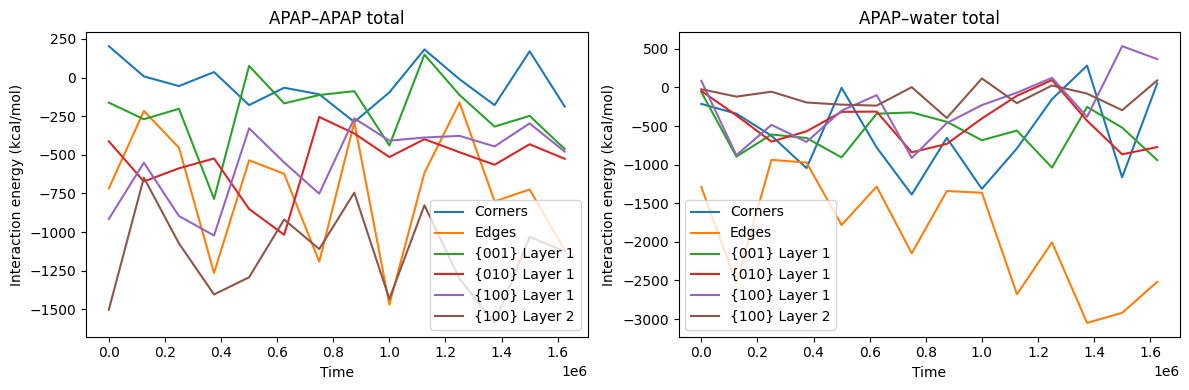

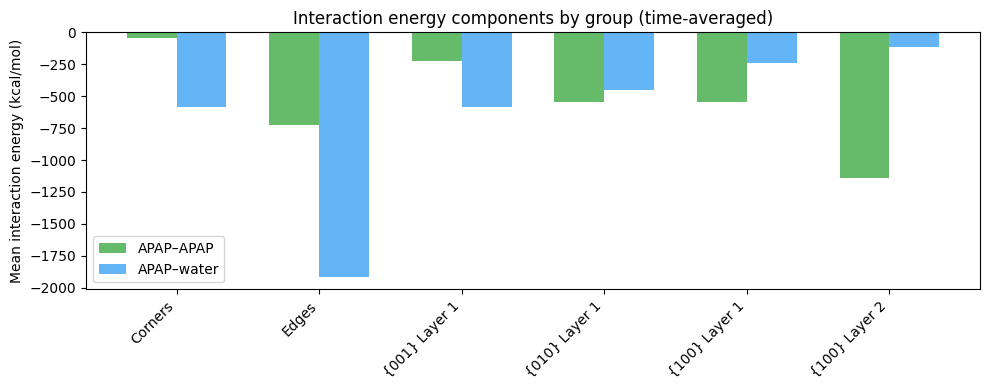

In [42]:

# Ensure group labels are attached
if 'group' not in energy_df.columns:
    energy_df['group'] = energy_df['mol'].map(mol_group_map)

group_cols = ['e_apap', 'e_water', 'e_apap_vdw', 'e_apap_coul', 'e_water_vdw', 'e_water_coul']
missing_cols = [c for c in group_cols if c not in energy_df.columns]
if missing_cols:
    print(f"Energy components missing ({missing_cols}); rerun the interaction energy cell above to populate vdW/electrostatic splits.")
    for col in missing_cols:
        energy_df[col] = 0.0

group_time = energy_df.groupby(['time', 'group'])[group_cols].sum().reset_index()

# Total interaction energy vs time per group
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for group_name, sub in group_time.groupby('group'):
    axes[0].plot(sub['time'], sub['e_apap'], label=group_name)
    axes[1].plot(sub['time'], sub['e_water'], label=group_name)
axes[0].set_title('APAP–APAP total')
axes[1].set_title('APAP–water total')
axes[0].set_xlabel('Time')
axes[1].set_xlabel('Time')
axes[0].set_ylabel('Interaction energy (kcal/mol)')
axes[1].set_ylabel('Interaction energy (kcal/mol)')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()

# Time-averaged decomposition by group
group_mean = group_time.groupby('group')[['e_apap_vdw', 'e_apap_coul', 'e_water_vdw', 'e_water_coul']].mean()
labels = group_mean.index.tolist()
x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
#ax.bar(x - width/2, group_mean['e_apap_vdw'], width=width, color='#2e7d32', label='APAP–APAP vdW')
ax.bar(x - width/2, group_mean['e_apap_coul'], width=width, bottom=group_mean['e_apap_vdw'], color='#66bb6a', label='APAP–APAP')
#ax.bar(x + width/2, group_mean['e_water_vdw'], width=width, color='#1565c0', label='APAP–water vdW')
ax.bar(x + width/2, group_mean['e_water_coul'], width=width, bottom=group_mean['e_water_vdw'], color='#64b5f6', label='APAP–water')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('Mean interaction energy (kcal/mol)')
ax.set_title('Interaction energy components by group (time-averaged)')
ax.legend()
plt.tight_layout()
plt.show()
